<img src=https://www.udc.es/export/sites/udc/silazarillo/_galeria_imgs/03_Simbolo_logo_cor.png_2063069294.png width="300" align="left">
<br />

# Modelos Avanzados de Aprendizaje Automático II
#### <font color=green>*Grado en Inteligencia Artificial*</font>

# Tema 2: Agrupamiento (clustering)

#### Ejercicio sobre el uso de algoritmos de agrupamiento ($k$-medias) sobre el conjunto de datos de los dígitos manuscritos

#### Se cargan las librerías necesarias:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
import seaborn as sns

#### Cargamos los datos (load_digits()). En la matriz de datos, cada fila se corresponde con la imagen de un dígito. Los píxeles de la imagen rectangular de 8×8 píxeles se han recolocado en una fila de 64 elementos. Por lo tanto, cada fila es un objeto o dato. Las características o propiedades de cada objeto son las intensidades de gris de cada pixel. Es decir, tenemos, para cada imagen, 64 propiedades.

In [4]:
digits = load_digits()
data =  digits.data
(n_samples, n_features) = data.shape

print(f"# samples: {n_samples}; # features: {n_features}")

# samples: 1797; # features: 64


#### Para visualizar mejor los dígitos, se invierten los colores.
#### Fijamos la semilla para inicializar los centroides, para que los resultados sean repetibles.
#### Fijamos $k$ teniendo en cuenta el número de dígitos diferentes.

In [5]:
data =  255 - data
np.random.seed(1)
k = 10

#### Se realiza el agrupamiento (clustering) mediante el uso del método [$k$-medias](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). 

In [6]:
kmeans = KMeans(n_clusters=k, init =  "random")
kmeans.fit(data)
clusters = kmeans.predict(data)

c:\Users\pablo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


#### Se muestra gráficamente los centroides de los agrupamientos.

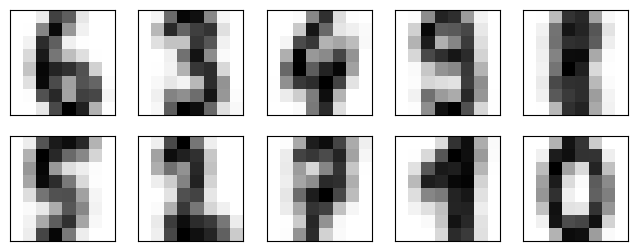

In [7]:
fig, ax = plt.subplots(2, 5, figsize=(8,3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation = "nearest", cmap = plt.cm.gray)
    

#### Se muestra gráficamente el resultado del agrupamiento: para cada una de las 10 clases, mostramos las imágenes que han sido asignadas a esa clase. 

cluster0
182elementos
cluster1
176elementos
cluster2
169elementos
cluster3
248elementos
cluster4
223elementos
cluster5
149elementos
cluster6
174elementos
cluster7
209elementos
cluster8
88elementos
cluster9
179elementos


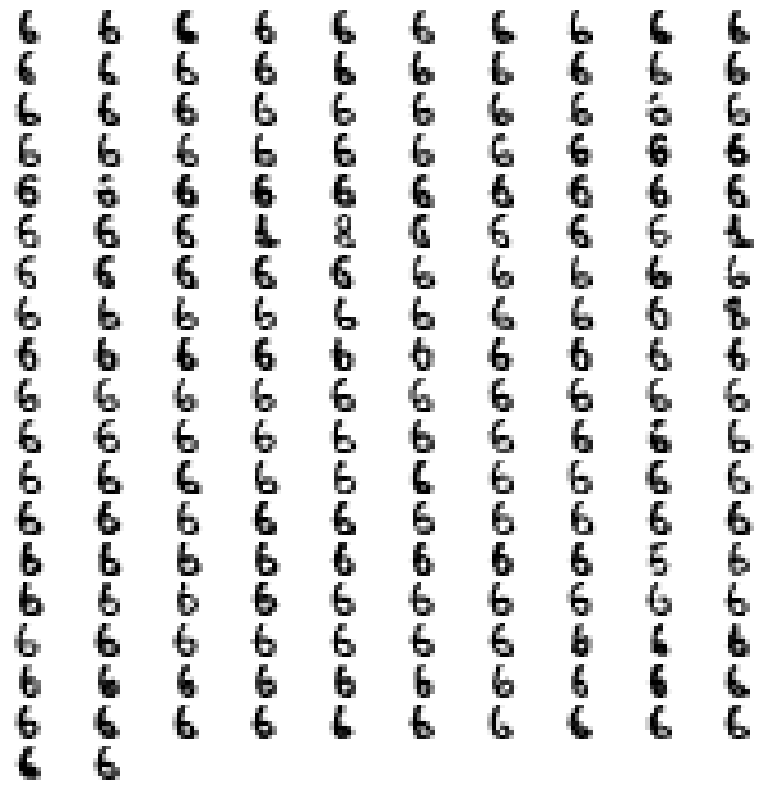

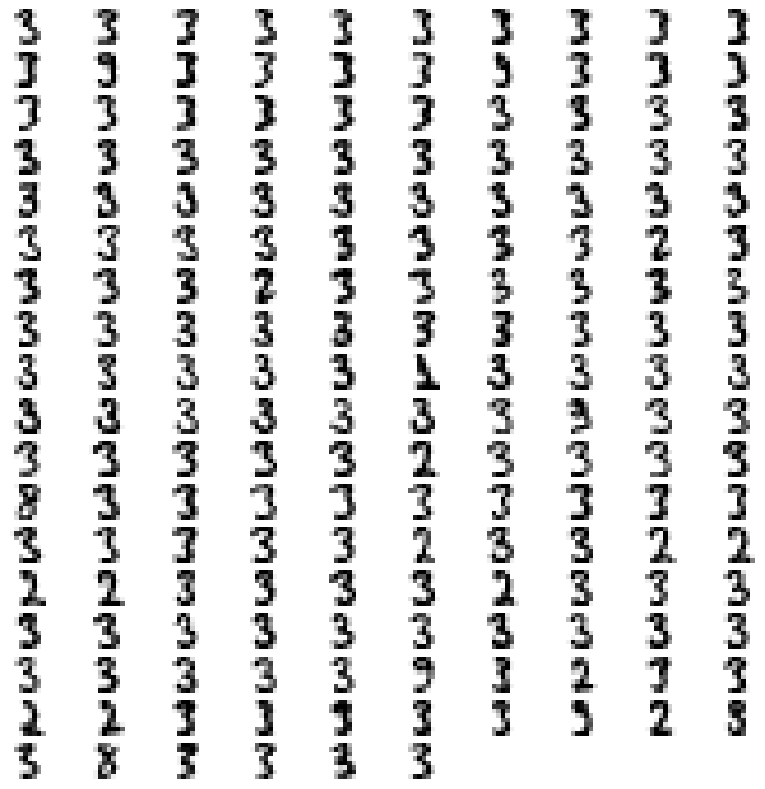

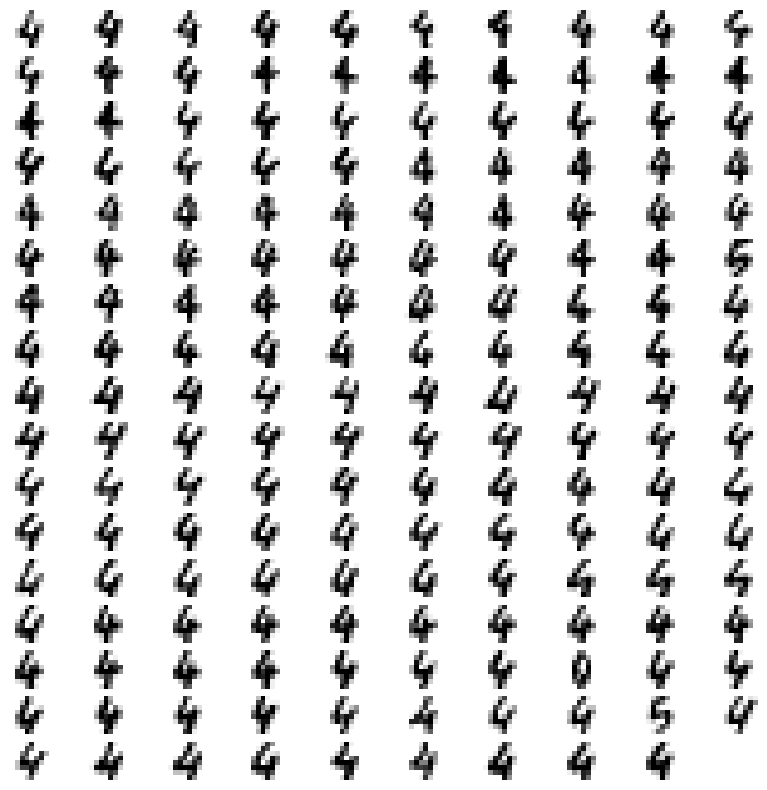

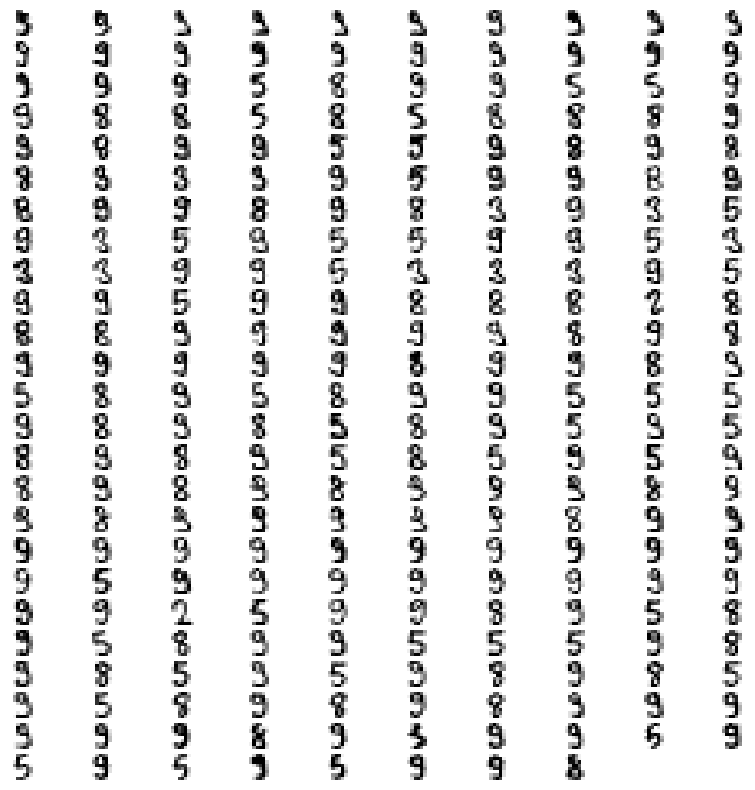

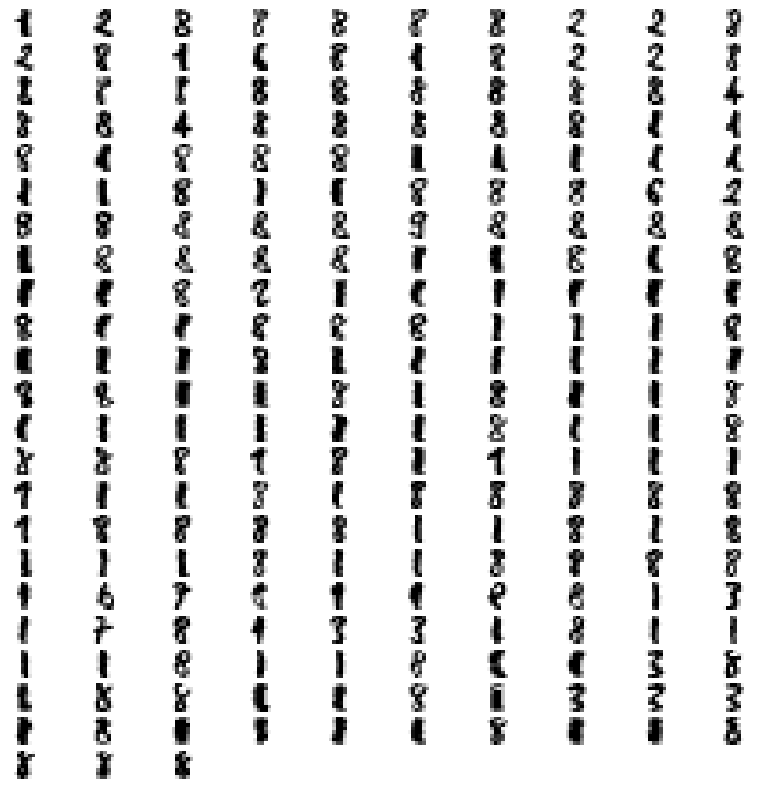

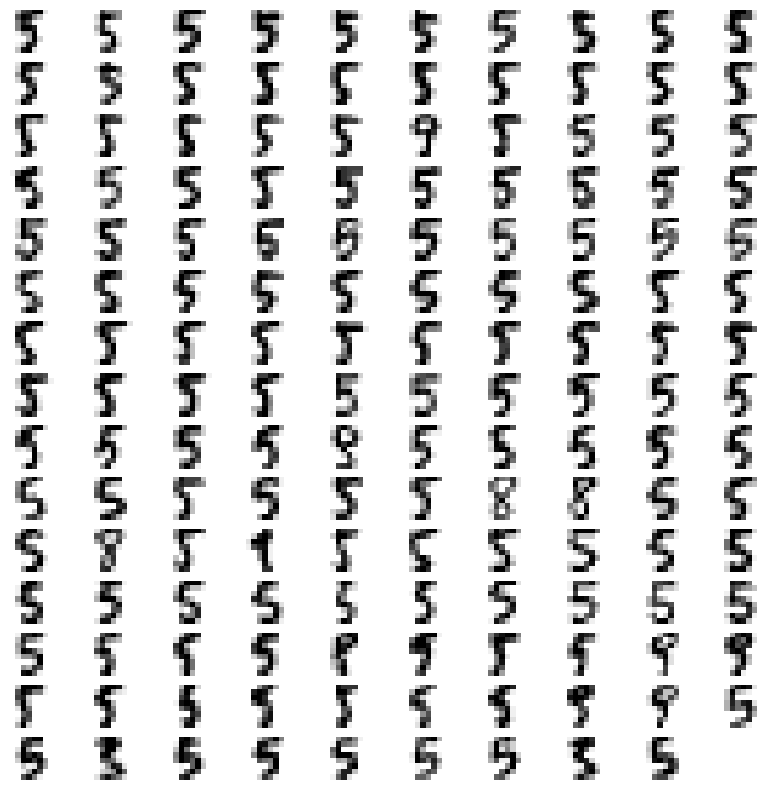

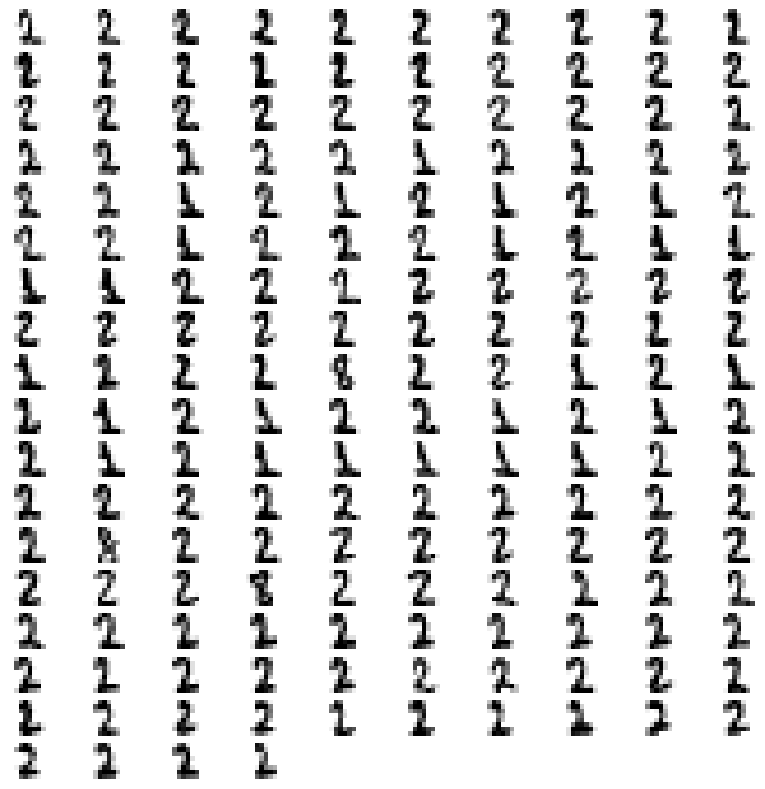

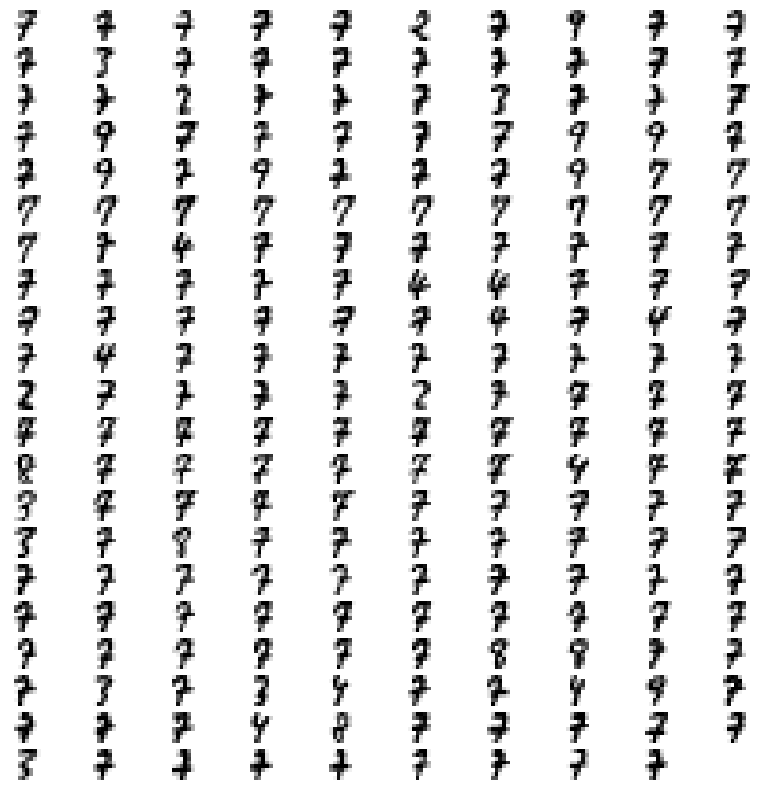

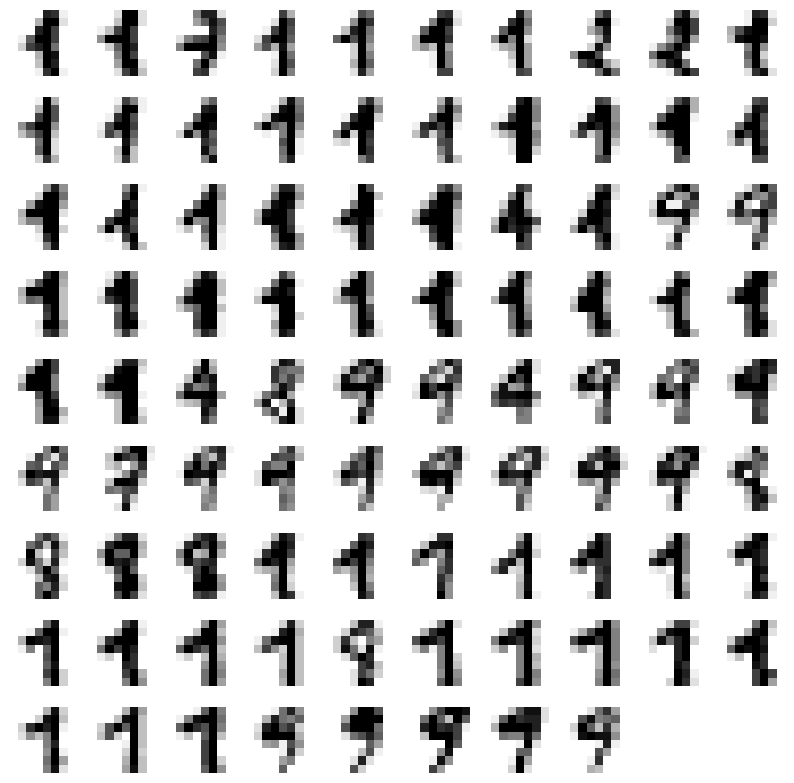

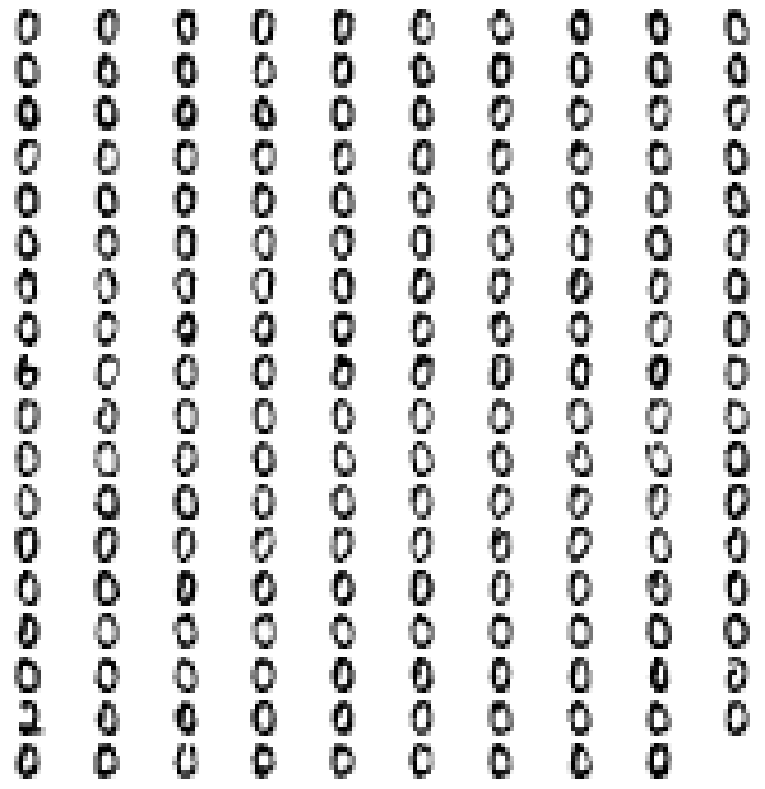

In [8]:
for i in range(0,k):
    fila = np.where(clusters == i)[0] # Filas en Z donde estan las imagenes en cada cluster
    num = fila.shape[0] # numero de imagenes de cada cluster
    r = int(np.floor(num/10.0)) #  numero de filas menos 1 en figura de salida
    print("cluster"+str(i))
    print(str(num) + "elementos")
    plt.figure(figsize=(10,10))
    for j in range(0, num):
        plt.subplot(r+1, 10, j+1)
        imagen = data[fila[j],]
        imagen = imagen.reshape(8,8)
        plt.imshow(imagen, cmap=plt.cm.gray)
        plt.axis("off")
    plt.show

#### Muestra una tabla con los resultados de las medidas de rendimiento (silhouette, v_measure, rand_indx) para al menos dos inicializaciones de los centroides. 

In [9]:
silhouette = silhouette_score(data, clusters)
silhouette

0.18262204667237633

#### Como k-means no sabe nada sobre la identidad del agrupamiento, las etiquetas 0-9 pueden estar permutadas. 
#### Hacer que cada etiqueta de clúster aprendida coincida con las etiquetas verdaderas que se encuentran en ellos.

In [10]:
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask],keepdims='True')[0]

#### Comprobar la precisión de la agrupación no supervisada a la hora de encontrar dígitos similares en los datos.

In [13]:
accuracy_score(digits.target, labels)


0.7941012799109627

#### Comprobamos la matriz de confusión para determinar en que dígitos se cometen más errores.

Text(113.9222222222222, 0.5, 'predicted label')

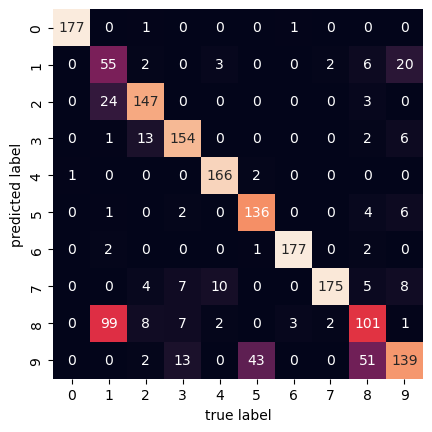

In [14]:
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square = True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')

#### Podemos utilizar el algoritmo t-SNE (t-distributed stochastic neighbor embedding) para preprocesar los datos antes de realizar k-means. t-SNE es un algoritmo de incrustación no lineal que es particularmente experto en preservar puntos dentro de clusters. Comprueba como cambian tanto la precisión como las medidas de rendimiento calculadas anteriormente. Utilizar la utilización aleatoria de los centroides.

In [15]:
#Project the data: thos ste`p will take several seconds`
tsne = TSNE(n_components=2, init= "random", random_state=0)
digits_proj = tsne.fit_transform(digits.data)

#Compute clusters
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

#Permute the labels
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask], keepdims = "True")[0]

#Compute the accuracy

accuracy_score(digits.target, labels)

c:\Users\pablo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


0.9415692821368948

## Razona los resultados obtenidos

In [ ]:
# Análisis del método de inicialización de centroides
# Análisis del método de elección del número de grupos (k)
# Comparación con el algoritmo t-SNE